# Build a K-Nearest Neighbors (KNN) Classification Model

#### 1. Load the data

In [2]:
import pandas as pd

df = pd.read_csv('../ML Data.csv', dtype={'ROLL NO.': str})
df.columns = df.columns.str.strip()  # remove stray leading/trailing spaces from headers
print(df.head())
print(df.shape)

       ROLL NO. GENDER  SOFTWARE ENGINEER   TOC  COMPUTER NETWORK  \
0  240104010001      M               30.0  30.0              30.0   
1  240104010002      F               30.0  40.0              45.0   
2  240104010003      M               38.0  38.0              38.0   
3  240104010004      M               59.0  55.0              57.0   
4  240104010005      M               30.0  30.0              30.0   

   MACHINE LEARNING  DATA WAREHOUSE GRADE RESULT  
0              30.0            30.0     C   PASS  
1              40.0            35.0     B   Pass  
2              38.0            38.0     B   Pass  
3              58.0            54.0     A   pass  
4              30.0            30.0     C   Pass  
(86, 9)


#### 2. Clean the data

In [3]:
numeric_cols = ['SOFTWARE ENGINEER', 'TOC', 'COMPUTER NETWORK', 'MACHINE LEARNING', 'DATA WAREHOUSE']

df['GENDER'] = df['GENDER'].str.strip().str.upper()
df['RESULT'] = df['RESULT'].str.strip().str.upper()
df['GRADE'] = df['GRADE'].str.strip().str.upper()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in ['GENDER', 'RESULT', 'GRADE']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.dropna(subset=['ROLL NO.'])
print(df.isnull().sum())
print(df['RESULT'].value_counts())

ROLL NO.             0
GENDER               0
SOFTWARE ENGINEER    0
TOC                  0
COMPUTER NETWORK     0
MACHINE LEARNING     0
DATA WAREHOUSE       0
GRADE                0
RESULT               0
dtype: int64
RESULT
PASS         66
FAIL          4
DISCHARGE     1
Name: count, dtype: int64


#### 3. Define features (X) and target (y)
The goal: predict whether a student **PASS**es or **FAIL**s based on their subject marks.

In [4]:
from sklearn.preprocessing import LabelEncoder

le_result = LabelEncoder()
df['RESULT_ENCODED'] = le_result.fit_transform(df['RESULT'])  # e.g. FAIL=0, PASS=1
print(dict(zip(le_result.classes_, le_result.transform(le_result.classes_))))

X = df[numeric_cols]
y = df['RESULT_ENCODED']

{'DISCHARGE': np.int64(0), 'FAIL': np.int64(1), 'PASS': np.int64(2)}


#### 4. Train-test split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (56, 5)
Test shape: (15, 5)


#### 5. Feature scaling
KNN relies on distances between points, so features must be on the same scale — otherwise subjects with naturally larger score ranges would dominate the distance calculation.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # use the SAME scaler fit on train, never refit on test

#### 6. Find the best value of k

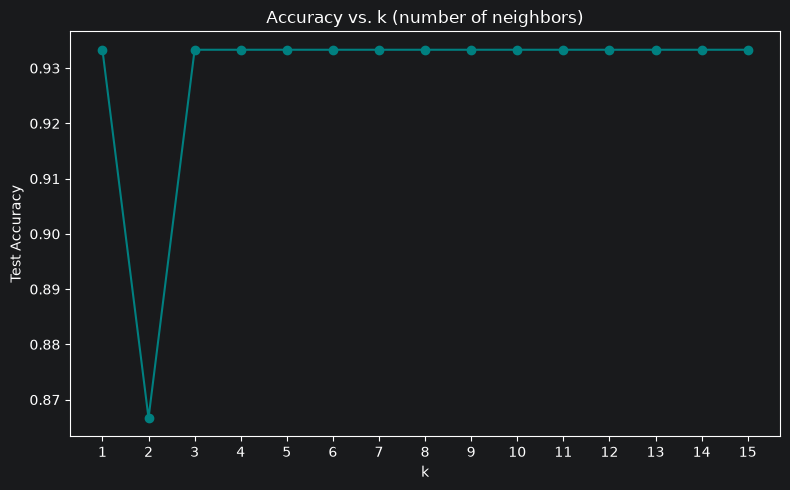

Best k: 1 with accuracy 0.9333


In [10]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_k))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='teal')
plt.title('Accuracy vs. k (number of neighbors)')
plt.xlabel('k')
plt.ylabel('Test Accuracy')
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best k: {best_k} with accuracy {max(accuracies):.4f}")

#### 7. Train the final KNN model

In [11]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

#### 8. Evaluate the model

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_result.classes_))

Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

   DISCHARGE       0.00      0.00      0.00         1
        FAIL       0.00      0.00      0.00         0
        PASS       1.00      1.00      1.00        14

    accuracy                           0.93        15
   macro avg       0.33      0.33      0.33        15
weighted avg       0.93      0.93      0.93        15



C:\Users\VAIBHAV DHIMAN\OneDrive\Desktop\Himesh Rana\Himesh ML Work\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\VAIBHAV DHIMAN\OneDrive\Desktop\Himesh Rana\Himesh ML Work\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\VAIBHAV DHIMAN\OneDrive\Desktop\Himesh Rana\Himesh ML Work\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` pa

#### 9. Confusion matrix

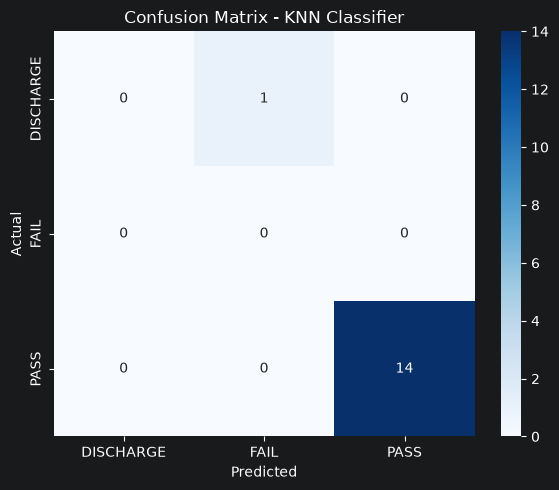

In [13]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_result.classes_, yticklabels=le_result.classes_)
plt.title('Confusion Matrix - KNN Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#### 10. Predict on a new/unseen student record
Example of using the trained model to classify a new student given their subject marks.

In [14]:
# Example: a new student's marks in the same subject order as numeric_cols
new_student = pd.DataFrame([[45, 50, 48, 52, 47]], columns=numeric_cols)
new_student_scaled = scaler.transform(new_student)

prediction = knn_model.predict(new_student_scaled)
print("Predicted result:", le_result.inverse_transform(prediction)[0])

Predicted result: PASS
